In [ ]:
from jaxcurve import LearnableCurve
from jaxcurveimpls import BezierCurve
import jax
import jax.numpy as jnp
from tqdm import tqdm, trange
import equinox as eqx
import qutip as qt

In [2]:
key = jax.random.key(44062)
curve = BezierCurve(32, [0, 0, 0], key)

ERROR:2026-03-29 22:52:11,473:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/bobby/CS/quantum/.venv/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/bobby/CS/quantum/.venv/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/bobby/CS/quantum/.venv/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


[0. 0. 0.] [0. 0. 0.]
2.665948


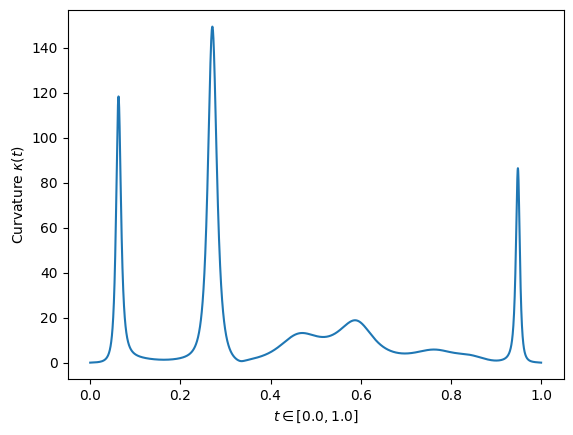

In [3]:
print( curve.position(1), curve.position(0) )
print( curve.arclength() )
curve.plot_curvature()

/home/bobby/CS/quantum/AnalogQSP/jaxcurve.py:126: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


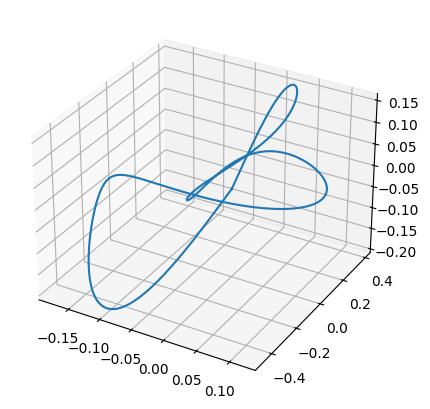

In [4]:
curve.plot_position()

In [5]:
def cost_fn( c: LearnableCurve, k: jnp.ndarray ):
    m2 = 10 * jnp.linalg.norm(c.magnus(2, k, 10_000) - jnp.array([0, 0, -1/6])) # -1/6
    m3 = 50 * jnp.linalg.norm(c.magnus(3, k, 10_000) - jnp.array([0, 0, 0])) # 0
    m4 = 100 * jnp.linalg.norm(c.magnus(4, k, 10_000) - jnp.array([0, 0, 1/120])) # 1/120

    return m2 + m3 + m4

STEPS = 50_000

bar = tqdm(total=STEPS)

def callback( step, loss, curve ):
    bar.set_postfix_str( f"Loss : {loss}" )
    bar.update(1)

curve : BezierCurve = curve.optimize(cost_fn, key, steps=STEPS, lr=5e-3, callback=callback)

100%|█████████▉| 49999/50000 [13:13<00:00, 58.30it/s, Loss : 0.23003742098808289] 

In [6]:
print( curve.magnus(2, key, 8192) )
print( curve.magnus(3, key, 8192) )
print( curve.magnus(4, key, 8192) )

[ 0.00105169 -0.00045136 -0.16995353]
[-0.00519968 -0.00300095 -0.00033799]
[3.16485457e-05 1.21878875e-05 8.65373854e-03]


1.2984594


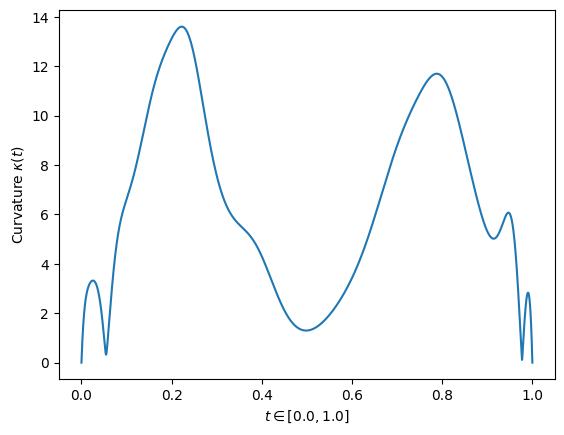

/home/bobby/CS/quantum/AnalogQSP/jaxcurve.py:126: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


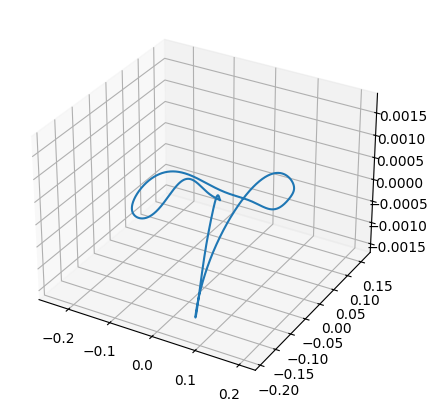

In [9]:
print(curve.arclength())
curve.plot_curvature()
curve.plot_position()

In [12]:
eqx.tree_serialise_leaves('bezier.eqx', curve)